In [41]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Define the data structure
class PortFolio(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr: float

In [42]:
# Define node functions
def cal_total(state: PortFolio) -> PortFolio:
    state['total_usd'] = float(state['amount_usd'] * 1.08)
    return state


In [43]:
def cal_inr(state: PortFolio) -> PortFolio:
    state['total_inr'] = float(state['total_usd'] * 85)
    return state

In [44]:

# Build the graph
builder = StateGraph(PortFolio)
builder.add_node("calculate_total_node", cal_total)
builder.add_node("calculate_inr_node", cal_inr)
builder.add_edge(START, "calculate_total_node")
builder.add_edge("calculate_total_node", "calculate_inr_node")
builder.add_edge("calculate_inr_node", END)

# Compile the graph
graph = builder.compile()

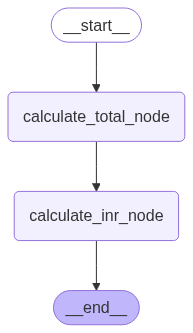

In [45]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
result = graph.invoke({
    "amount_usd": 1000.0
})
result

{'amount_usd': 1000.0, 'total_usd': 1080.0, 'total_inr': 91800.0}